# Module 5, Lecture 2: Anomaly Detection Algorithms

This notebook demonstrates the core ideas covered in Lecture 2 using one small host-window traffic dataset.

Covered methods:

1. Gaussian / z-score anomaly detection  
2. Isolation Forest  
3. One-Class SVM  
4. PCA as dimensionality reduction before modeling  
5. Autoencoder-style reconstruction error  

Main idea: an anomaly score is an investigation lead, not proof of attack.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import classification_report, confusion_matrix

## 1. Build the running host-window dataset

Each row represents one host during one 5-minute window.

The labels are included only so we can inspect results at the end.

The anomaly detectors below should not use the labels during training.

In [3]:
rng = np.random.default_rng(7)

n_normal = 120

normal = pd.DataFrame({
    "host": [f"N{i:03d}" for i in range(n_normal)],
    "connections_per_5min": rng.poisson(lam=14, size=n_normal).clip(3, 35),
    "unique_destinations_per_5min": rng.poisson(lam=5, size=n_normal).clip(1, 16),
    "failed_connections_per_5min": rng.poisson(lam=1, size=n_normal).clip(0, 7),
    "bytes_out_per_5min": rng.lognormal(mean=np.log(3.0), sigma=0.35, size=n_normal),
    "dns_queries_per_5min": rng.poisson(lam=6, size=n_normal).clip(0, 22),
    "true_label": "normal"
})

lecture_examples = pd.DataFrame([
    {
        "host": "H1",
        "connections_per_5min": 12,
        "unique_destinations_per_5min": 4,
        "failed_connections_per_5min": 0,
        "bytes_out_per_5min": 3,
        "dns_queries_per_5min": 6,
        "true_label": "normal"
    },
    {
        "host": "H2",
        "connections_per_5min": 15,
        "unique_destinations_per_5min": 5,
        "failed_connections_per_5min": 1,
        "bytes_out_per_5min": 4,
        "dns_queries_per_5min": 7,
        "true_label": "normal"
    },
    {
        "host": "H3",
        "connections_per_5min": 11,
        "unique_destinations_per_5min": 3,
        "failed_connections_per_5min": 0,
        "bytes_out_per_5min": 2,
        "dns_queries_per_5min": 5,
        "true_label": "normal"
    },
    {
        "host": "H4_scanning_like",
        "connections_per_5min": 260,
        "unique_destinations_per_5min": 190,
        "failed_connections_per_5min": 80,
        "bytes_out_per_5min": 5,
        "dns_queries_per_5min": 8,
        "true_label": "suspicious"
    },
    {
        "host": "H5_outbound_spike",
        "connections_per_5min": 18,
        "unique_destinations_per_5min": 6,
        "failed_connections_per_5min": 0,
        "bytes_out_per_5min": 500,
        "dns_queries_per_5min": 8,
        "true_label": "suspicious"
    }
])

df = pd.concat([normal, lecture_examples], ignore_index=True)

feature_cols = [
    "connections_per_5min",
    "unique_destinations_per_5min",
    "failed_connections_per_5min",
    "bytes_out_per_5min",
    "dns_queries_per_5min"
]

df.tail(10)

,host,connections_per_5min,unique_destinations_per_5min,failed_connections_per_5min,bytes_out_per_5min,dns_queries_per_5min,true_label
115,N115,16,8,1,1.947431,4,normal
116,N116,17,4,0,2.786760,4,normal
117,N117,17,8,1,3.307559,5,normal
118,N118,13,7,2,4.086262,7,normal
119,N119,14,2,1,3.470183,8,normal
120,H1,12,4,0,3.000000,6,normal
121,H2,15,5,1,4.000000,7,normal
122,H3,11,3,0,2.000000,5,normal
123,H4_scanning_like,260,190,80,5.000000,8,suspicious
124,H5_outbound_spike,18,6,0,500.000000,8,suspicious


In [4]:
df[feature_cols].describe().round(2)

,connections_per_5min,unique_destinations_per_5min,failed_connections_per_5min,bytes_out_per_5min,dns_queries_per_5min
count,125.00,125.00,125.00,125.00,125.00
mean,16.05,6.28,1.61,7.38,6.22
std,22.32,16.68,7.13,44.43,2.44
min,3.00,1.00,0.00,1.21,1.00
25%,12.00,3.00,0.00,2.53,4.00
50%,14.00,5.00,1.00,3.28,6.00
75%,17.00,6.00,2.00,4.13,8.00
max,260.00,190.00,80.00,500.00,13.00


## 2. Helper function: score, rank, and decision

Most anomaly detectors produce some version of:

Score: how unusual the record appears.  
Rank: which records should be inspected first.  
Decision: whether the record crosses a threshold.  

The decision is not truth.  
It is a triage signal.

In [5]:
def show_top_records(data, score_col, decision_col=None, n=10):
    cols = ["host", "true_label"] + feature_cols + [score_col]
    if decision_col:
        cols.append(decision_col)
    return data[cols].sort_values(score_col, ascending=False).head(n).reset_index(drop=True)

## 3. Gaussian / z-score anomaly detection

Gaussian-style anomaly detection is the simplest starting point.

It works best when one meaningful feature has a stable normal range.

Here, we use `bytes_out_per_5min` to detect a possible outbound data spike.

In [6]:
baseline_bytes_out = np.array([2, 3, 2, 4, 3, 2], dtype=float)
new_value = 500.0

mean_bytes = baseline_bytes_out.mean()
std_bytes = baseline_bytes_out.std(ddof=1)
z_score = (new_value - mean_bytes) / std_bytes

print(f"Baseline values: {baseline_bytes_out.tolist()} MB")
print(f"Mean: {mean_bytes:.2f} MB")
print(f"Standard deviation: {std_bytes:.2f} MB")
print(f"New value: {new_value:.2f} MB")
print(f"Z-score: {z_score:.2f}")

Baseline values: [2.0, 3.0, 2.0, 4.0, 3.0, 2.0] MB
Mean: 2.67 MB
Standard deviation: 0.82 MB
New value: 500.00 MB
Z-score: 609.11


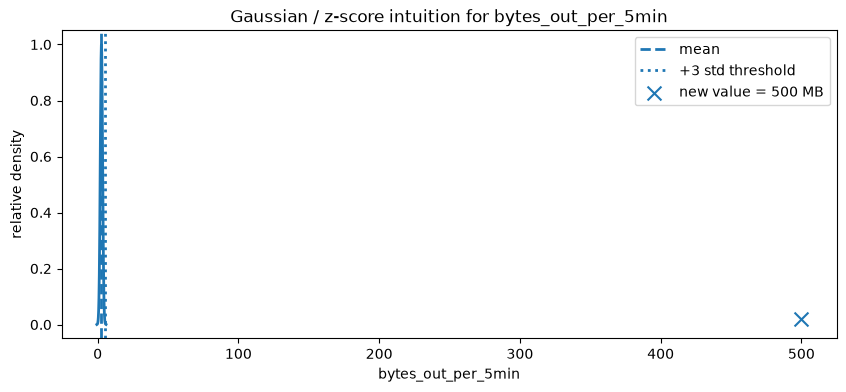

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

x = np.linspace(mean_bytes - 4*std_bytes, mean_bytes + 4*std_bytes, 400)
y = np.exp(-0.5*((x - mean_bytes)/std_bytes)**2)

ax.plot(x, y, linewidth=2)
ax.axvline(mean_bytes, linestyle="--", linewidth=2, label="mean")
ax.axvline(mean_bytes + 3*std_bytes, linestyle=":", linewidth=2, label="+3 std threshold")
ax.scatter([new_value], [0.02], s=100, marker="x", label="new value = 500 MB")

ax.set_title("Gaussian / z-score intuition for bytes_out_per_5min")
ax.set_xlabel("bytes_out_per_5min")
ax.set_ylabel("relative density")
ax.legend()
plt.show()

Now apply the same idea to the full dataset.

We compute a z-score for `bytes_out_per_5min`.

A large absolute z-score means the value is far from the dataset baseline.

In [8]:
z_df = df.copy()

normal_baseline = z_df[z_df["true_label"] == "normal"]["bytes_out_per_5min"]

mu = normal_baseline.mean()
sigma = normal_baseline.std(ddof=1)

z_df["gaussian_z_score"] = (z_df["bytes_out_per_5min"] - mu) / sigma
z_df["gaussian_anomaly_score"] = z_df["gaussian_z_score"].abs()
z_df["gaussian_alert"] = z_df["gaussian_anomaly_score"] > 3

show_top_records(z_df, "gaussian_anomaly_score", "gaussian_alert", n=8)

,host,true_label,connections_per_5min,unique_destinations_per_5min,failed_connections_per_5min,bytes_out_per_5min,dns_queries_per_5min,gaussian_anomaly_score,gaussian_alert
0,H5_outbound_spike,suspicious,18,6,0,500.000000,8,414.767200,True
1,N050,normal,14,3,1,8.062019,4,3.894365,True
2,N109,normal,17,5,2,7.724600,6,3.612548,True
3,N036,normal,12,6,0,6.100828,3,2.256353,False
4,N104,normal,13,4,0,5.646801,5,1.877144,False
5,N096,normal,12,5,0,1.213690,6,1.825446,False
6,N028,normal,16,4,1,1.269256,9,1.779037,False
7,N075,normal,15,3,1,5.468238,9,1.728006,False


Interpretation:

A high z-score can tell us that outbound volume is unusual.

It cannot tell us whether the cause is exfiltration, research transfer, cloud backup, software update, or a misconfigured sync client.

## 4. Isolation Forest

Isolation Forest uses multiple features at the same time.

It does not try to describe normal behavior directly.

It asks:

How quickly can this record be separated from the rest?

In [9]:
X = df[feature_cols].copy()

scaler_if = StandardScaler()
X_scaled = scaler_if.fit_transform(X)

iso = IsolationForest(
    n_estimators=300,
    contamination=0.04,
    random_state=7
)

iso.fit(X_scaled)

if_df = df.copy()

# sklearn returns higher decision_function values for more normal records.
# We multiply by -1 so higher means more suspicious.
if_df["isolation_forest_score"] = -iso.decision_function(X_scaled)
if_df["isolation_forest_alert"] = iso.predict(X_scaled) == -1

show_top_records(if_df, "isolation_forest_score", "isolation_forest_alert", n=10)

,host,true_label,connections_per_5min,unique_destinations_per_5min,failed_connections_per_5min,bytes_out_per_5min,dns_queries_per_5min,isolation_forest_score,isolation_forest_alert
0,H4_scanning_like,suspicious,260,190,80,5.000000,8,0.353034,True
1,H5_outbound_spike,suspicious,18,6,0,500.000000,8,0.153592,True
2,N082,normal,19,10,0,2.965935,13,0.031775,True
3,N103,normal,15,5,5,4.950624,8,0.007630,True
4,N029,normal,19,8,2,2.368261,1,0.000788,True
5,N113,normal,21,2,0,2.125180,12,-0.000033,False
6,N004,normal,12,2,0,4.663394,12,-0.020815,False
7,N110,normal,11,5,0,3.855890,13,-0.027819,False
8,N106,normal,8,7,1,2.777906,1,-0.028624,False
9,N099,normal,9,4,3,5.168094,4,-0.034675,False


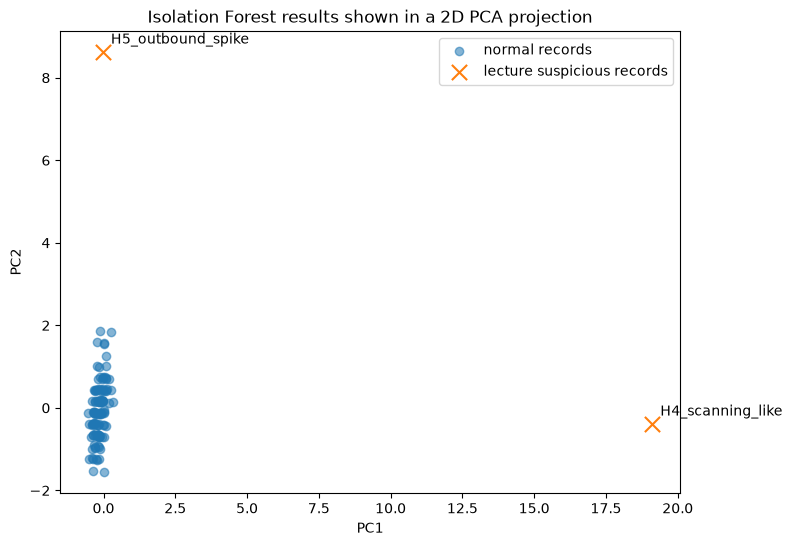

In [10]:
pca_for_plot = PCA(n_components=2, random_state=7)
X_2d = pca_for_plot.fit_transform(X_scaled)

plot_df = if_df.copy()
plot_df["PC1"] = X_2d[:, 0]
plot_df["PC2"] = X_2d[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))

normal_points = plot_df[plot_df["true_label"] == "normal"]
suspicious_points = plot_df[plot_df["true_label"] == "suspicious"]

ax.scatter(normal_points["PC1"], normal_points["PC2"], alpha=0.55, label="normal records")
ax.scatter(suspicious_points["PC1"], suspicious_points["PC2"], s=120, marker="x", label="lecture suspicious records")

for _, row in suspicious_points.iterrows():
    ax.annotate(row["host"], (row["PC1"], row["PC2"]), xytext=(6, 6), textcoords="offset points")

ax.set_title("Isolation Forest results shown in a 2D PCA projection")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.show()

Isolation Forest is useful when suspicious behavior is unusual in combination.

For example, H4 is unusual because connection count, destination count, and failed connection count are all high together.

The model gives a score, not a full explanation.

## 5. One-Class SVM

One-Class SVM learns the region where mostly normal records live.

Records inside the learned region are treated as normal.

Records outside the region are treated as suspicious.

Scaling is required because feature scale strongly affects the boundary.

In [11]:
oc_df = df.copy()

train_normal = oc_df["true_label"] == "normal"

scaler_oc = StandardScaler()
X_train_normal_scaled = scaler_oc.fit_transform(oc_df.loc[train_normal, feature_cols])
X_all_scaled = scaler_oc.transform(oc_df[feature_cols])

ocsvm = OneClassSVM(
    kernel="rbf",
    nu=0.04,
    gamma="scale"
)

ocsvm.fit(X_train_normal_scaled)

# Higher negative value means farther outside normal region.
oc_df["one_class_svm_score"] = -ocsvm.decision_function(X_all_scaled)
oc_df["one_class_svm_alert"] = ocsvm.predict(X_all_scaled) == -1

show_top_records(oc_df, "one_class_svm_score", "one_class_svm_alert", n=10)

,host,true_label,connections_per_5min,unique_destinations_per_5min,failed_connections_per_5min,bytes_out_per_5min,dns_queries_per_5min,one_class_svm_score,one_class_svm_alert
0,H5_outbound_spike,suspicious,18,6,0,500.000000,8,0.431200,True
1,H4_scanning_like,suspicious,260,190,80,5.000000,8,0.431200,True
2,N071,normal,10,2,2,5.236582,5,0.000471,True
3,N056,normal,16,2,0,4.102141,2,0.000431,True
4,N044,normal,17,7,3,2.171850,7,0.000348,True
5,N027,normal,25,8,2,3.380335,7,0.000344,True
6,N066,normal,20,4,0,5.101232,3,0.000264,True
7,N073,normal,21,2,1,4.617054,7,0.000196,True
8,N022,normal,18,9,0,4.973466,6,0.000178,True
9,N109,normal,17,5,2,7.724600,6,0.000159,True


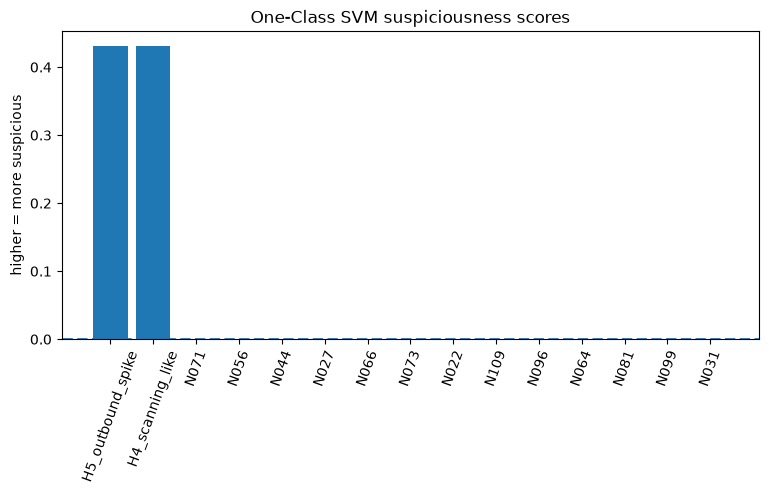

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))

sorted_scores = oc_df.sort_values("one_class_svm_score", ascending=False).head(15)
ax.bar(sorted_scores["host"], sorted_scores["one_class_svm_score"])
ax.axhline(0, linestyle="--", linewidth=2)
ax.set_title("One-Class SVM suspiciousness scores")
ax.set_ylabel("higher = more suspicious")
ax.tick_params(axis="x", rotation=70)
plt.show()

The important parameters are:

`nu` controls how many records the model is willing to treat as outside the normal region.

`gamma` controls how flexible the boundary is.

Too strict can create many false positives.

Too flexible can wrap around noise and miss anomalies.

## 6. PCA as dimensionality reduction before modeling

PCA reduces many related features into fewer component features.

The first components capture the largest patterns of variation.

Those PCA components can be used for:

Dimensionality reduction.  
Noise reduction.  
Visualization.  
Preprocessing before anomaly detection.

In [13]:
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(df[feature_cols])

pca = PCA(n_components=len(feature_cols), random_state=7)
X_pca_all = pca.fit_transform(X_scaled_pca)

explained = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(feature_cols))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained.round(3)

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.594,0.594
1,PC2,0.212,0.806
2,PC3,0.186,0.993
3,PC4,0.005,0.997
4,PC5,0.003,1.000


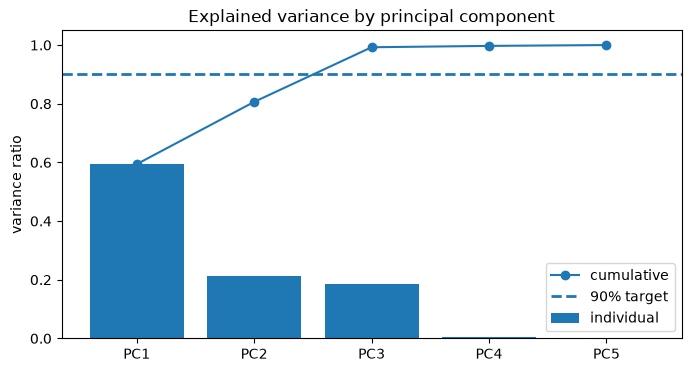

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(explained["component"], explained["explained_variance_ratio"], label="individual")
ax.plot(explained["component"], explained["cumulative_variance"], marker="o", label="cumulative")
ax.axhline(0.90, linestyle="--", linewidth=2, label="90% target")

ax.set_title("Explained variance by principal component")
ax.set_ylabel("variance ratio")
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

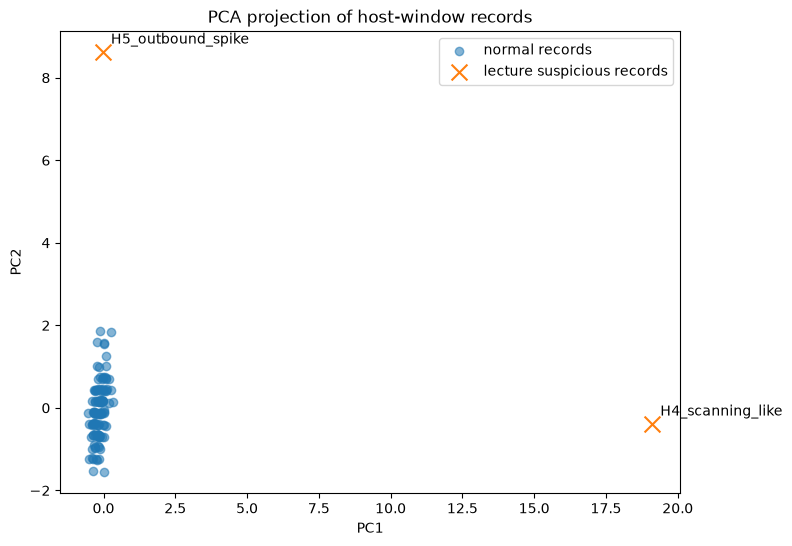

In [15]:
pca_2 = PCA(n_components=2, random_state=7)
X_pca_2 = pca_2.fit_transform(X_scaled_pca)

pca_plot_df = df.copy()
pca_plot_df["PC1"] = X_pca_2[:, 0]
pca_plot_df["PC2"] = X_pca_2[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))

normal_points = pca_plot_df[pca_plot_df["true_label"] == "normal"]
suspicious_points = pca_plot_df[pca_plot_df["true_label"] == "suspicious"]

ax.scatter(normal_points["PC1"], normal_points["PC2"], alpha=0.55, label="normal records")
ax.scatter(suspicious_points["PC1"], suspicious_points["PC2"], s=130, marker="x", label="lecture suspicious records")

for _, row in suspicious_points.iterrows():
    ax.annotate(row["host"], (row["PC1"], row["PC2"]), xytext=(6, 6), textcoords="offset points")

ax.set_title("PCA projection of host-window records")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.show()

Now use PCA as preprocessing.

The model below does not train on the original raw feature columns.

It trains on selected PCA component features.

In [16]:
# Choose enough components to preserve at least 90% variance.
n_components_90 = int(np.argmax(explained["cumulative_variance"].values >= 0.90) + 1)

pca_reducer = PCA(n_components=n_components_90, random_state=7)
X_pc_features = pca_reducer.fit_transform(X_scaled_pca)

pc_feature_names = [f"PC{i+1}" for i in range(n_components_90)]
pc_df = pd.DataFrame(X_pc_features, columns=pc_feature_names)
pc_df.insert(0, "host", df["host"].values)
pc_df["true_label"] = df["true_label"].values

pc_df.tail()

,host,PC1,PC2,PC3,true_label
120,H1,-0.320202,-0.117871,0.017507,normal
121,H2,-0.100342,0.170276,0.292460,normal
122,H3,-0.407167,-0.413234,-0.263418,normal
123,H4_scanning_like,19.102733,-0.388368,-0.308055,suspicious
124,H5_outbound_spike,-0.032266,8.625543,-7.078601,suspicious


In [17]:
iso_on_pca = IsolationForest(
    n_estimators=300,
    contamination=0.04,
    random_state=7
)

iso_on_pca.fit(X_pc_features)

pca_model_df = df.copy()
pca_model_df["pca_isolation_forest_score"] = -iso_on_pca.decision_function(X_pc_features)
pca_model_df["pca_isolation_forest_alert"] = iso_on_pca.predict(X_pc_features) == -1

show_top_records(pca_model_df, "pca_isolation_forest_score", "pca_isolation_forest_alert", n=10)

,host,true_label,connections_per_5min,unique_destinations_per_5min,failed_connections_per_5min,bytes_out_per_5min,dns_queries_per_5min,pca_isolation_forest_score,pca_isolation_forest_alert
0,H5_outbound_spike,suspicious,18,6,0,500.000000,8,0.246779,True
1,H4_scanning_like,suspicious,260,190,80,5.000000,8,0.177950,True
2,N082,normal,19,10,0,2.965935,13,0.059876,True
3,N029,normal,19,8,2,2.368261,1,0.028314,True
4,N110,normal,11,5,0,3.855890,13,0.019903,True
5,N106,normal,8,7,1,2.777906,1,-0.000829,False
6,N004,normal,12,2,0,4.663394,12,-0.016846,False
7,N113,normal,21,2,0,2.125180,12,-0.047619,False
8,N035,normal,14,6,2,2.016616,11,-0.049827,False
9,N095,normal,10,1,1,3.197819,2,-0.050561,False


PCA reduces dimensions.

The downstream anomaly detector still produces the anomaly score.

Too few components may remove useful anomaly signals.

## 7. Autoencoder-style reconstruction error

An autoencoder learns to reconstruct its input.

For anomaly detection:

Train mostly on normal traffic.  
Normal records should reconstruct well.  
Unusual records should reconstruct poorly.  
High reconstruction error becomes the anomaly signal.  

This notebook uses `MLPRegressor` as a compact autoencoder-style model.

It learns to map scaled input features back to the same scaled input features.

In [18]:
ae_df = df.copy()

train_normal = ae_df["true_label"] == "normal"

scaler_ae = StandardScaler()
X_train_ae = scaler_ae.fit_transform(ae_df.loc[train_normal, feature_cols])
X_all_ae = scaler_ae.transform(ae_df[feature_cols])

autoencoder = MLPRegressor(
    hidden_layer_sizes=(3,),
    activation="tanh",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.01,
    max_iter=2500,
    random_state=7
)

autoencoder.fit(X_train_ae, X_train_ae)

X_reconstructed = autoencoder.predict(X_all_ae)

reconstruction_error = np.mean((X_all_ae - X_reconstructed) ** 2, axis=1)

ae_df["autoencoder_reconstruction_error"] = reconstruction_error

normal_errors = ae_df.loc[train_normal, "autoencoder_reconstruction_error"]
threshold = normal_errors.quantile(0.96)

ae_df["autoencoder_alert"] = ae_df["autoencoder_reconstruction_error"] > threshold

show_top_records(ae_df, "autoencoder_reconstruction_error", "autoencoder_alert", n=10)

,host,true_label,connections_per_5min,unique_destinations_per_5min,failed_connections_per_5min,bytes_out_per_5min,dns_queries_per_5min,autoencoder_reconstruction_error,autoencoder_alert
0,H5_outbound_spike,suspicious,18,6,0,500.000000,8,34415.883296,True
1,H4_scanning_like,suspicious,260,190,80,5.000000,8,3884.015198,True
2,N050,normal,14,3,1,8.062019,4,1.795531,True
3,N004,normal,12,2,0,4.663394,12,1.438188,True
4,N113,normal,21,2,0,2.125180,12,1.435463,True
5,N109,normal,17,5,2,7.724600,6,1.425609,True
6,N106,normal,8,7,1,2.777906,1,1.368512,True
7,N029,normal,19,8,2,2.368261,1,1.296169,False
8,N013,normal,12,10,0,4.832118,9,1.179323,False
9,N073,normal,21,2,1,4.617054,7,1.137104,False


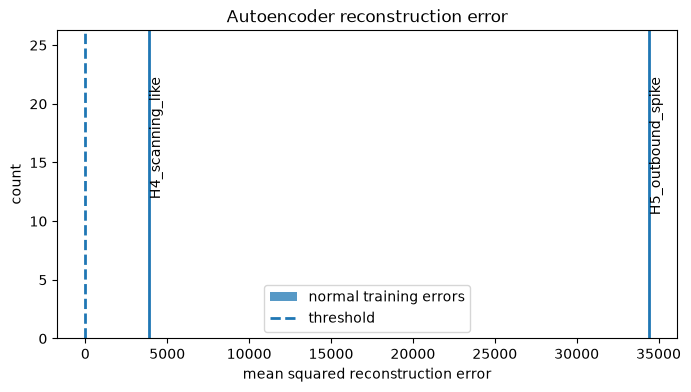

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(normal_errors, bins=25, alpha=0.75, label="normal training errors")
ax.axvline(threshold, linestyle="--", linewidth=2, label="threshold")

for _, row in ae_df[ae_df["true_label"] == "suspicious"].iterrows():
    ax.axvline(row["autoencoder_reconstruction_error"], linewidth=2)
    ax.text(
        row["autoencoder_reconstruction_error"],
        ax.get_ylim()[1] * 0.85,
        row["host"],
        rotation=90,
        va="top"
    )

ax.set_title("Autoencoder reconstruction error")
ax.set_xlabel("mean squared reconstruction error")
ax.set_ylabel("count")
ax.legend()
plt.show()

Feature-level reconstruction error helps explain why a record looked unusual.

In [20]:
feature_level_error = pd.DataFrame(
    (X_all_ae - X_reconstructed) ** 2,
    columns=feature_cols
)

feature_level_error.insert(0, "host", ae_df["host"].values)
feature_level_error["total_error"] = ae_df["autoencoder_reconstruction_error"].values
feature_level_error["true_label"] = ae_df["true_label"].values

feature_level_error.sort_values("total_error", ascending=False).head(8).round(3)

,host,connections_per_5min,unique_destinations_per_5min,failed_connections_per_5min,bytes_out_per_5min,dns_queries_per_5min,total_error,true_label
124,H5_outbound_spike,0.013,0.148,0.151,172071.981,7.123,34415.883,suspicious
123,H4_scanning_like,4008.457,8335.420,7074.613,0.040,1.546,3884.015,suspicious
50,N050,0.306,0.712,0.156,7.329,0.475,1.796,normal
4,N004,0.002,0.841,0.000,3.913,2.435,1.438,normal
113,N113,3.011,2.676,0.035,0.074,1.382,1.435,normal
109,N109,0.090,0.913,0.020,5.459,0.647,1.426,normal
106,N106,1.402,3.433,0.059,0.849,1.099,1.369,normal
29,N029,0.127,0.343,0.005,3.740,2.266,1.296,normal


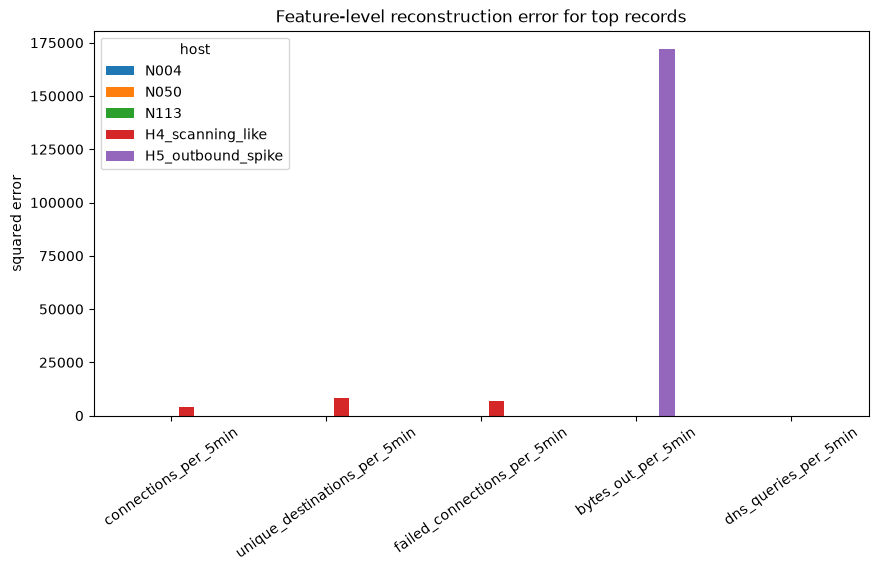

In [21]:
top_hosts = feature_level_error.sort_values("total_error", ascending=False).head(5)["host"].tolist()

plot_error = feature_level_error[feature_level_error["host"].isin(top_hosts)].set_index("host")[feature_cols]

fig, ax = plt.subplots(figsize=(10, 5))
plot_error.T.plot(kind="bar", ax=ax)

ax.set_title("Feature-level reconstruction error for top records")
ax.set_ylabel("squared error")
ax.tick_params(axis="x", rotation=35)
plt.show()

Feature-level interpretation:

High error in `bytes_out_per_5min` may suggest exfiltration or a large transfer.

High error in `failed_connections_per_5min` may suggest brute force or scanning.

High error in `dns_queries_per_5min` may suggest suspicious lookup behavior.

## 8. Compare all methods

Different algorithms score unusualness differently.

The goal is not to blindly trust one method.

The goal is to understand what each method sees.

In [22]:
comparison = pd.DataFrame({
    "host": df["host"],
    "true_label": df["true_label"],
    "gaussian_bytes_score": z_df["gaussian_anomaly_score"],
    "isolation_forest_score": if_df["isolation_forest_score"],
    "one_class_svm_score": oc_df["one_class_svm_score"],
    "pca_iforest_score": pca_model_df["pca_isolation_forest_score"],
    "autoencoder_error": ae_df["autoencoder_reconstruction_error"]
})

# Convert each score to percentile rank so scores are easier to compare.
score_cols = [
    "gaussian_bytes_score",
    "isolation_forest_score",
    "one_class_svm_score",
    "pca_iforest_score",
    "autoencoder_error"
]

for col in score_cols:
    comparison[col + "_rank"] = comparison[col].rank(pct=True)

rank_cols = ["host", "true_label"] + [col + "_rank" for col in score_cols]

comparison[rank_cols].sort_values("isolation_forest_score_rank", ascending=False).head(12).round(3)

,host,true_label,gaussian_bytes_score_rank,isolation_forest_score_rank,one_class_svm_score_rank,pca_iforest_score_rank,autoencoder_error_rank
123,H4_scanning_like,suspicious,0.856,1.000,0.996,0.992,0.992
124,H5_outbound_spike,suspicious,1.000,0.992,0.996,1.000,1.000
82,N082,normal,0.280,0.984,0.760,0.984,0.576
103,N103,normal,0.824,0.976,0.840,0.848,0.904
29,N029,normal,0.592,0.968,0.776,0.976,0.944
113,N113,normal,0.728,0.960,0.864,0.944,0.968
4,N004,normal,0.704,0.952,0.872,0.952,0.976
110,N110,normal,0.296,0.944,0.832,0.968,0.888
106,N106,normal,0.400,0.936,0.752,0.960,0.952
99,N099,normal,0.920,0.928,0.896,0.328,0.632


In [23]:
summary = comparison[comparison["true_label"] == "suspicious"][rank_cols].copy()
summary.round(3)

,host,true_label,gaussian_bytes_score_rank,isolation_forest_score_rank,one_class_svm_score_rank,pca_iforest_score_rank,autoencoder_error_rank
123,H4_scanning_like,suspicious,0.856,1.000,0.996,0.992,0.992
124,H5_outbound_spike,suspicious,1.000,0.992,0.996,1.000,1.000


### Final interpretation

Gaussian / z-score detection is easy to explain, but it sees only one feature at a time.

Isolation Forest can catch unusual multifeature combinations.

One-Class SVM learns a boundary around mostly normal behavior.

PCA reduces the original feature space before modeling or visualization.

Autoencoders use reconstruction error as the anomaly signal.

In every case, the score means investigate.

It does not prove an attack.